# **Exploratory Data Analysis**

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [2]:
eda_df = pd.read_csv('dataset/cleaned/ecommerce_cleaned.csv')

In [3]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000123 entries, 0 to 1000122
Data columns (total 31 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_date              1000123 non-null  object 
 1   order_year              1000123 non-null  int64  
 2   order_month             1000123 non-null  int64  
 3   customer_name           1000123 non-null  object 
 4   gender                  1000123 non-null  object 
 5   age                     1000123 non-null  int64  
 6   customer_segment        1000123 non-null  object 
 7   country                 1000123 non-null  object 
 8   category                1000123 non-null  object 
 9   sub_category            1000123 non-null  object 
 10  unit_price_usd          1000123 non-null  float64
 11  quantity                1000123 non-null  int64  
 12  discount_percent        1000123 non-null  int64  
 13  revenue_usd             1000123 non-null  float64
 14  pr

In [4]:
# Missing values (%)
print(((eda_df.isnull().sum() / len(eda_df)) * 100).to_string())

order_date               0.00
order_year               0.00
order_month              0.00
customer_name            0.00
gender                   0.00
age                      0.00
customer_segment         0.00
country                  0.00
category                 0.00
sub_category             0.00
unit_price_usd           0.00
quantity                 0.00
discount_percent         0.00
revenue_usd              0.00
profit_usd               0.00
profit_margin_percent    0.00
payment_method           0.00
shipping_method          0.00
shipping_cost_usd        0.00
delivery_days            0.00
shipping_country         0.00
rating                   0.00
customer_loyalty_score   0.00
coupon_used              0.00
session_duration_min     0.00
pages_visited            0.00
abandoned_cart_before    0.00
fraud_risk_score         0.00
device_type              0.00
campaign_source          0.00
traffic_source           0.00


### **Identify outliers, distribution, and skewed data using Histogram**

In [5]:
eda_df.columns

Index(['order_date', 'order_year', 'order_month', 'customer_name', 'gender',
       'age', 'customer_segment', 'country', 'category', 'sub_category',
       'unit_price_usd', 'quantity', 'discount_percent', 'revenue_usd',
       'profit_usd', 'profit_margin_percent', 'payment_method',
       'shipping_method', 'shipping_cost_usd', 'delivery_days',
       'shipping_country', 'rating', 'customer_loyalty_score', 'coupon_used',
       'session_duration_min', 'pages_visited', 'abandoned_cart_before',
       'fraud_risk_score', 'device_type', 'campaign_source', 'traffic_source'],
      dtype='object')

In [6]:
eda_df.sample(5)

,order_date,order_year,order_month,customer_name,gender,age,customer_segment,country,category,sub_category,unit_price_usd,quantity,discount_percent,revenue_usd,profit_usd,profit_margin_percent,payment_method,shipping_method,shipping_cost_usd,delivery_days,shipping_country,rating,customer_loyalty_score,coupon_used,session_duration_min,pages_visited,abandoned_cart_before,fraud_risk_score,device_type,campaign_source,traffic_source
116927,2026-01-21 23:05:18.480318,2026,1,Chelsea Blair,Female,72,Premium,United States,Home,Furniture,92.45,4,15,314.33,93.45,29.73,Apple Pay,Express,19.25,2,United States,3,12.80,Yes,29.80,16,No,77.00,Mobile,Affiliate,Direct
460491,2024-03-05 15:03:41.630260,2024,3,Jeffrey Mcdonald,Male,74,Regular,Australia,Health,Personal Care,189.81,1,10,170.83,64.20,37.58,Apple Pay,Next Day,7.26,4,Australia,2,81.60,No,16.70,3,Yes,4.00,Mobile,Google Ads,Referral
669406,2024-02-04 20:25:27.525858,2024,2,Todd Collins,Male,24,Premium,Italy,Electronics,Laptops,419.96,1,10,377.96,106.36,28.14,PayPal,Express,22.10,13,Italy,3,20.80,No,4.10,11,Yes,99.60,Mobile,Google Ads,Email
154877,2024-09-15 23:14:41.414410,2024,9,Karen Gonzalez,Female,72,Premium,United Kingdom,Home,Appliances,253.66,1,15,215.61,54.17,25.12,Debit Card,Express,13.44,11,United Kingdom,5,55.70,Yes,6.00,12,Yes,9.30,Desktop,Facebook,Referral
913189,2025-10-16 14:53:21.508566,2025,10,Gary Woods,Male,20,Regular,Canada,Health,Fitness,31.53,2,5,59.91,22.77,38.01,PayPal,Next Day,13.76,6,Canada,1,50.10,Yes,39.50,11,No,90.30,Desktop,Google Ads,Referral


### IQR to Detect Outlier for All Numeric Columns

In [7]:
numeric_cols = eda_df.select_dtypes(include='number')

In [8]:
# Detect outliers in numeric columns using the IQR rule.

for col in numeric_cols:
    Q1 = eda_df[col].quantile(0.25)
    Q3 = eda_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = eda_df[
        (eda_df[col] < lower) |
        (eda_df[col] > upper)
    ]

    count = len(outliers)
    percent = (count / len(eda_df)) * 100

    if round(percent, 2) > 0:
        print(f"{col}: {count:,} outliers")
        print(f"{col} in percent (%) : {percent:.2f}% outliers\n")

unit_price_usd: 47,098 outliers
unit_price_usd in percent (%) : 4.71% outliers

revenue_usd: 49,298 outliers
revenue_usd in percent (%) : 4.93% outliers

profit_usd: 56,873 outliers
profit_usd in percent (%) : 5.69% outliers

profit_margin_percent: 352 outliers
profit_margin_percent in percent (%) : 0.04% outliers



Based on the IQR method, four columns were identified as containing potential outliers for all numeric columns: **``unit_price_usd``**, **``revenue_usd``**, **``profit_usd``**, and **``profit_margin_percent``**. Among these, **``unit_price_usd``** (4.71%), **``revenue_usd``** (4.93%), and **``profit_usd``** (5.69%) exhibit a relatively similar proportion of outliers (approximately 5%), whereas **``profit_margin_percent``** contains only 0.04% outliers. To determine whether these detected outliers represent legitimate business observations or anomalous values, visualizations such as box plots and histograms will be used for further investigation.

### Numerical and Categorical Variables

In [9]:
categorical_cols = [
    'gender',
    'customer_segment',
    'category',
    'payment_method',
    'shipping_method',
    'device_type',
    'campaign_source',
    'traffic_source',
    'coupon_used',
    'abandoned_cart_before'
]

discrete_cols = [
    'quantity',
    'rating',
    'delivery_days',
    'discount_percent',
    'pages_visited',
    'order_month'
]

continuous_cols = [
    'unit_price_usd',
    'revenue_usd',
    'profit_usd',
    'profit_margin_percent',
    'shipping_cost_usd',
    'session_duration_min',
    'fraud_risk_score',
    'customer_loyalty_score'
]

### Histogram for Continuous Variables

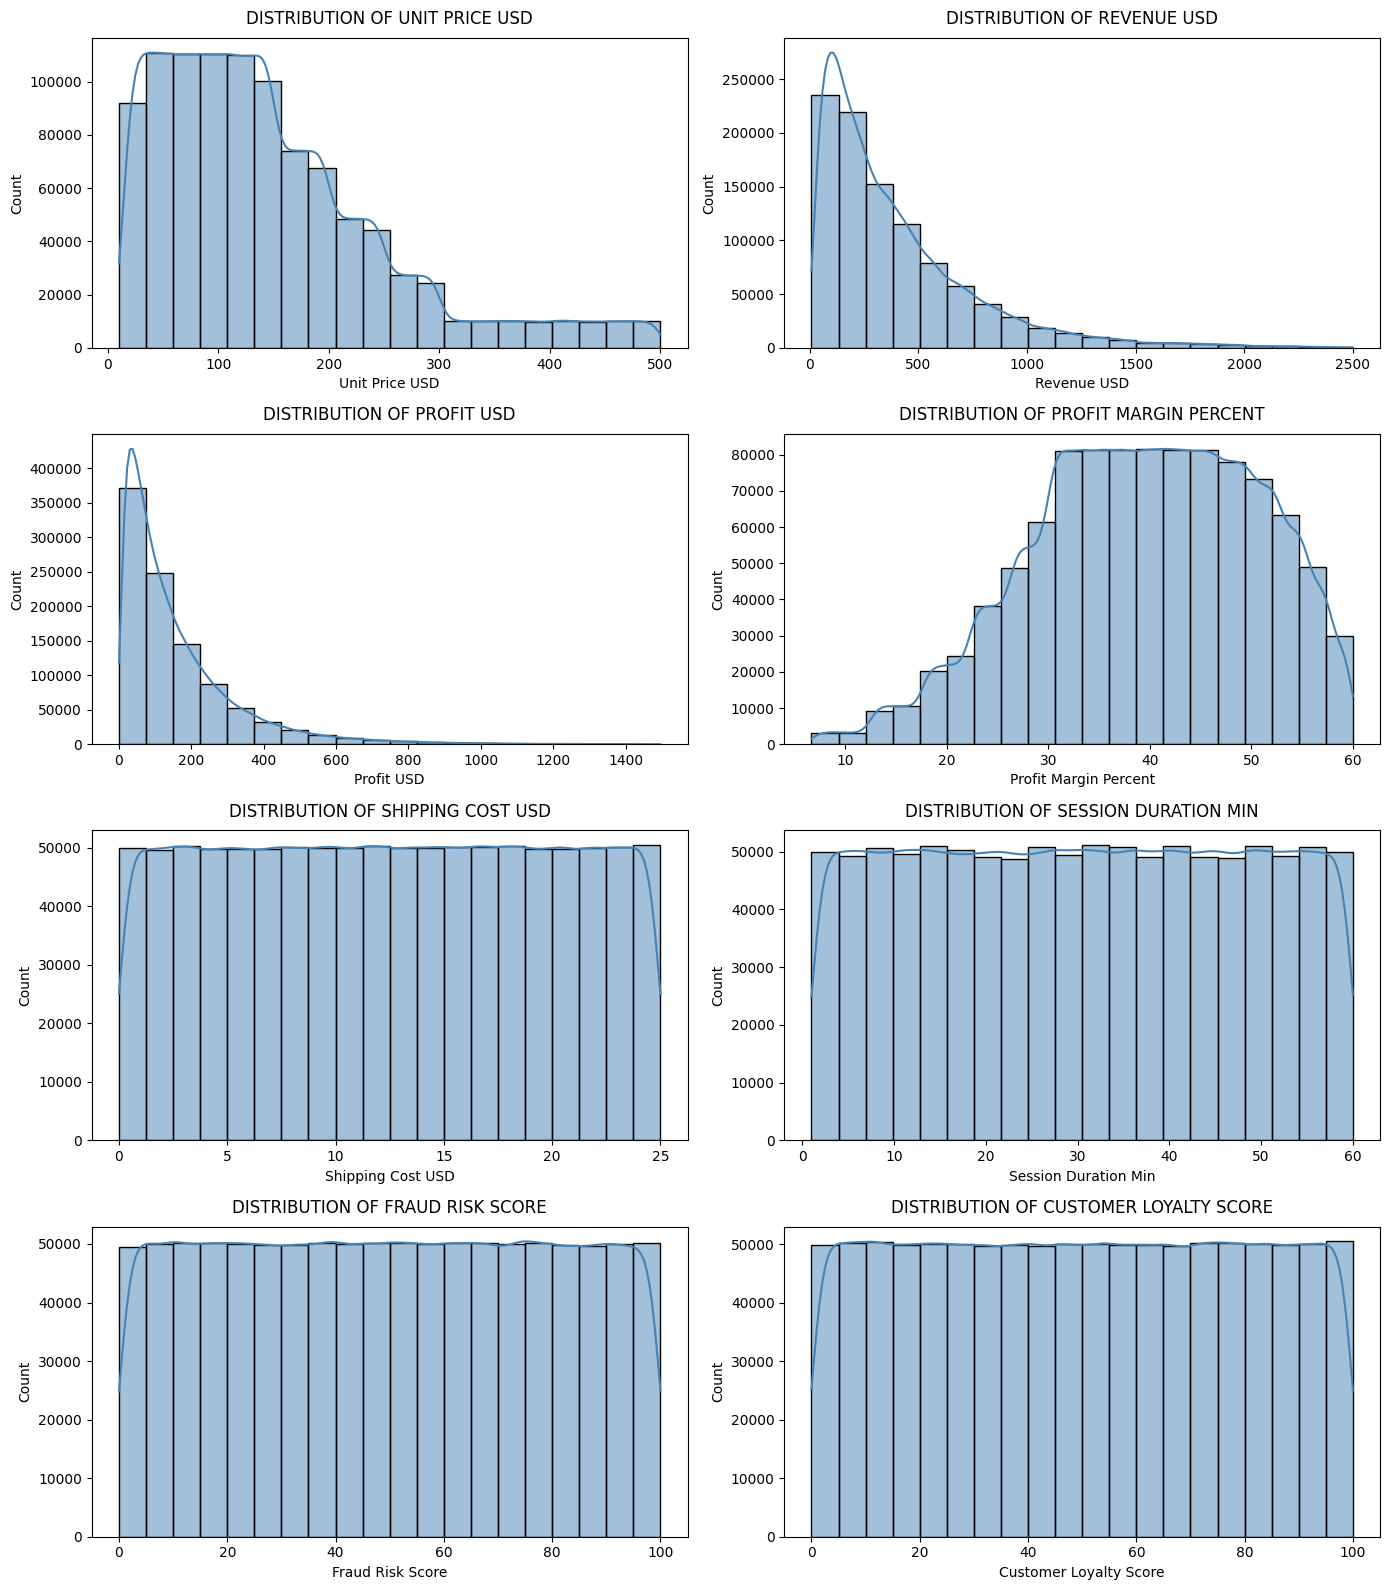

In [10]:
# Histogram Distribution of Continuous Variables

n_cols = 2
n_rows = math.ceil(len(continuous_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()  
for i, cons in enumerate(continuous_cols):
    ax = axes[i]
    
    sns.histplot(
        data=eda_df,
        x=cons,
        bins=20,
        ax=ax,
        color='steelblue',
        kde=True
    )
    
    # Title & labels
    title = f'Distribution of {cons.replace("_", " ")}'.upper()
    xlabel = cons.replace('_', ' ').title().replace('Usd', 'USD')
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')

# Hide empty subplots if not exact multiple of 2
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Boxplot for Continuous and Discrete Variables

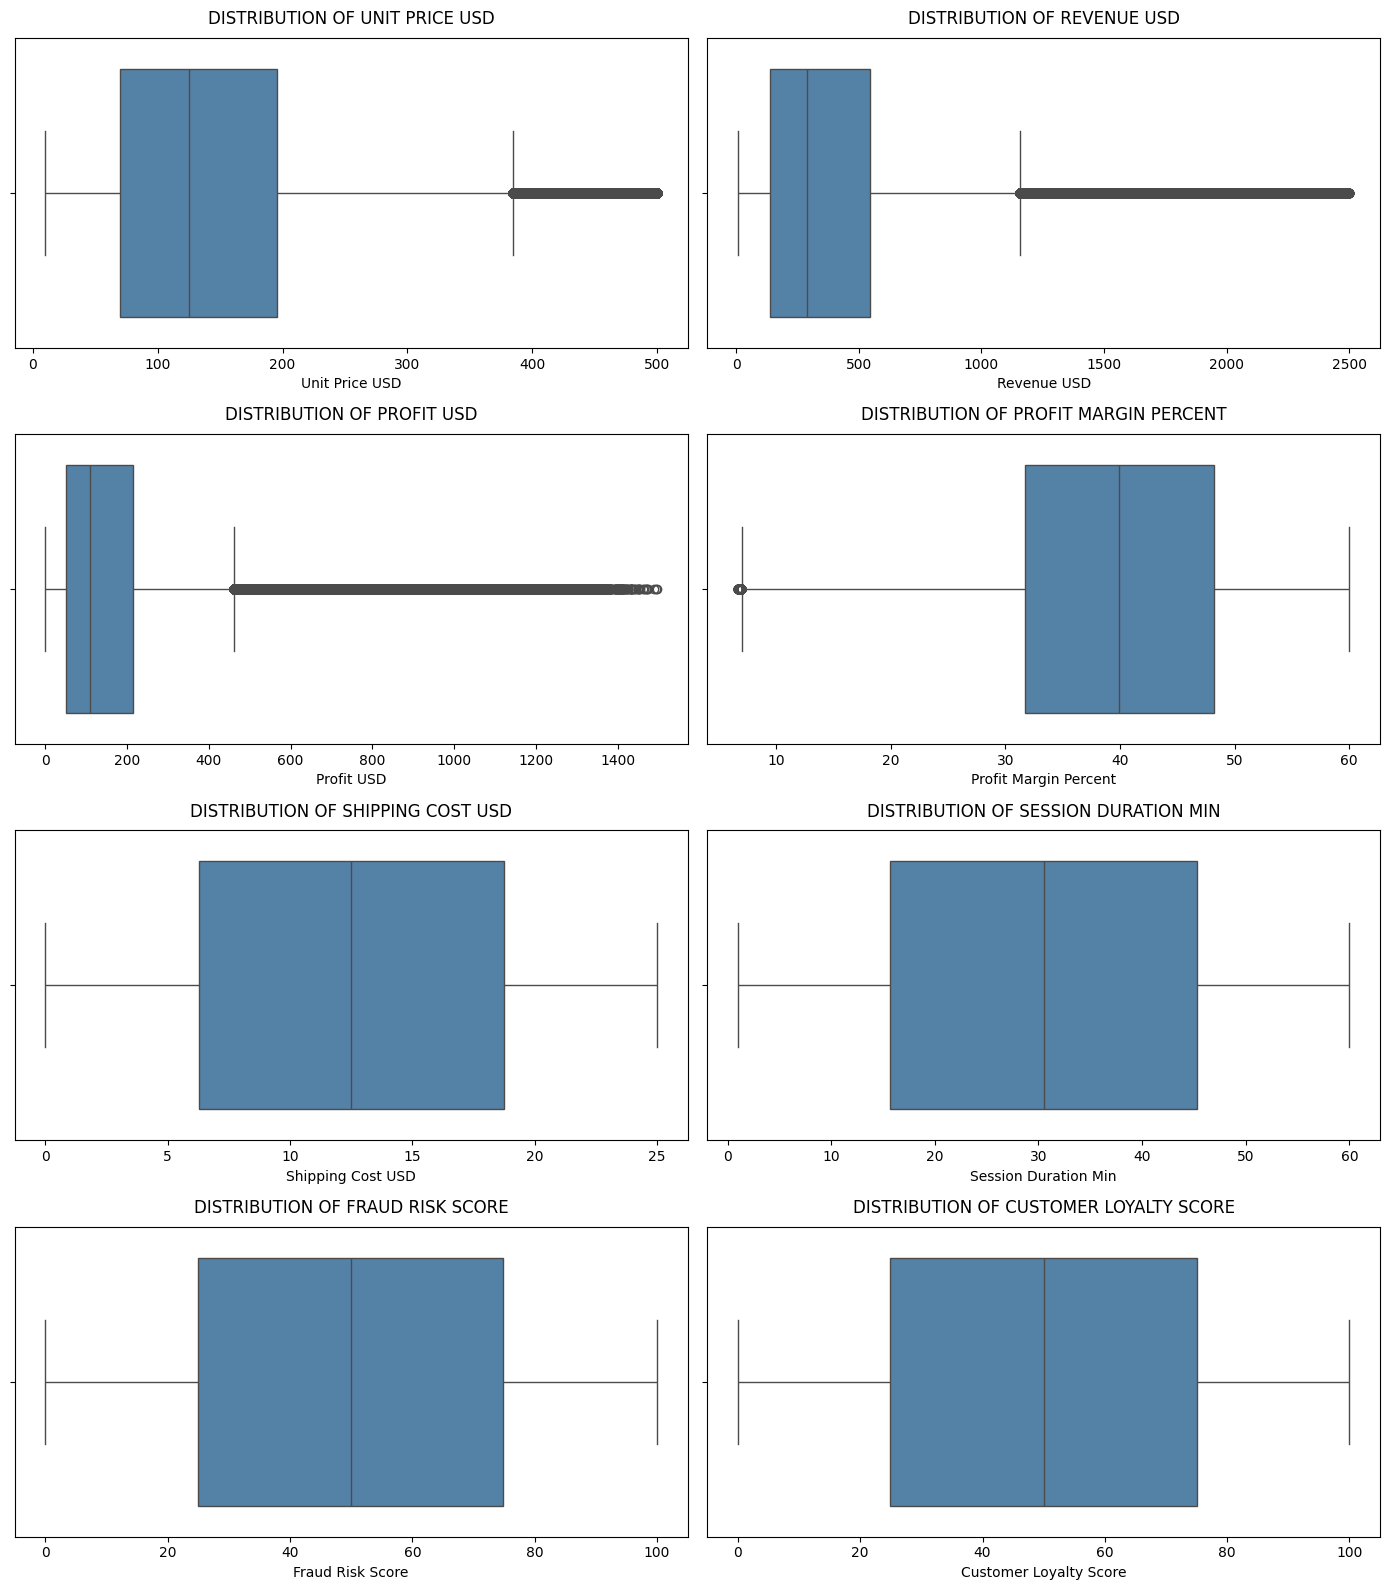

In [11]:
# Boxplot Distribution of Continuous Variables
n_cols = 2
n_rows = math.ceil(len(continuous_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()  
for i, cons in enumerate(continuous_cols):
    ax = axes[i]
    
    sns.boxplot(
        data=eda_df,
        x=cons,
        ax=ax,
        color='steelblue'
    )
    
    # Title & labels
    title = f'Distribution of {cons.replace("_", " ")}'.upper()
    xlabel = cons.replace('_', ' ').title().replace('Usd', 'USD')
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)

# Hide empty subplots if not exact multiple of 2
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

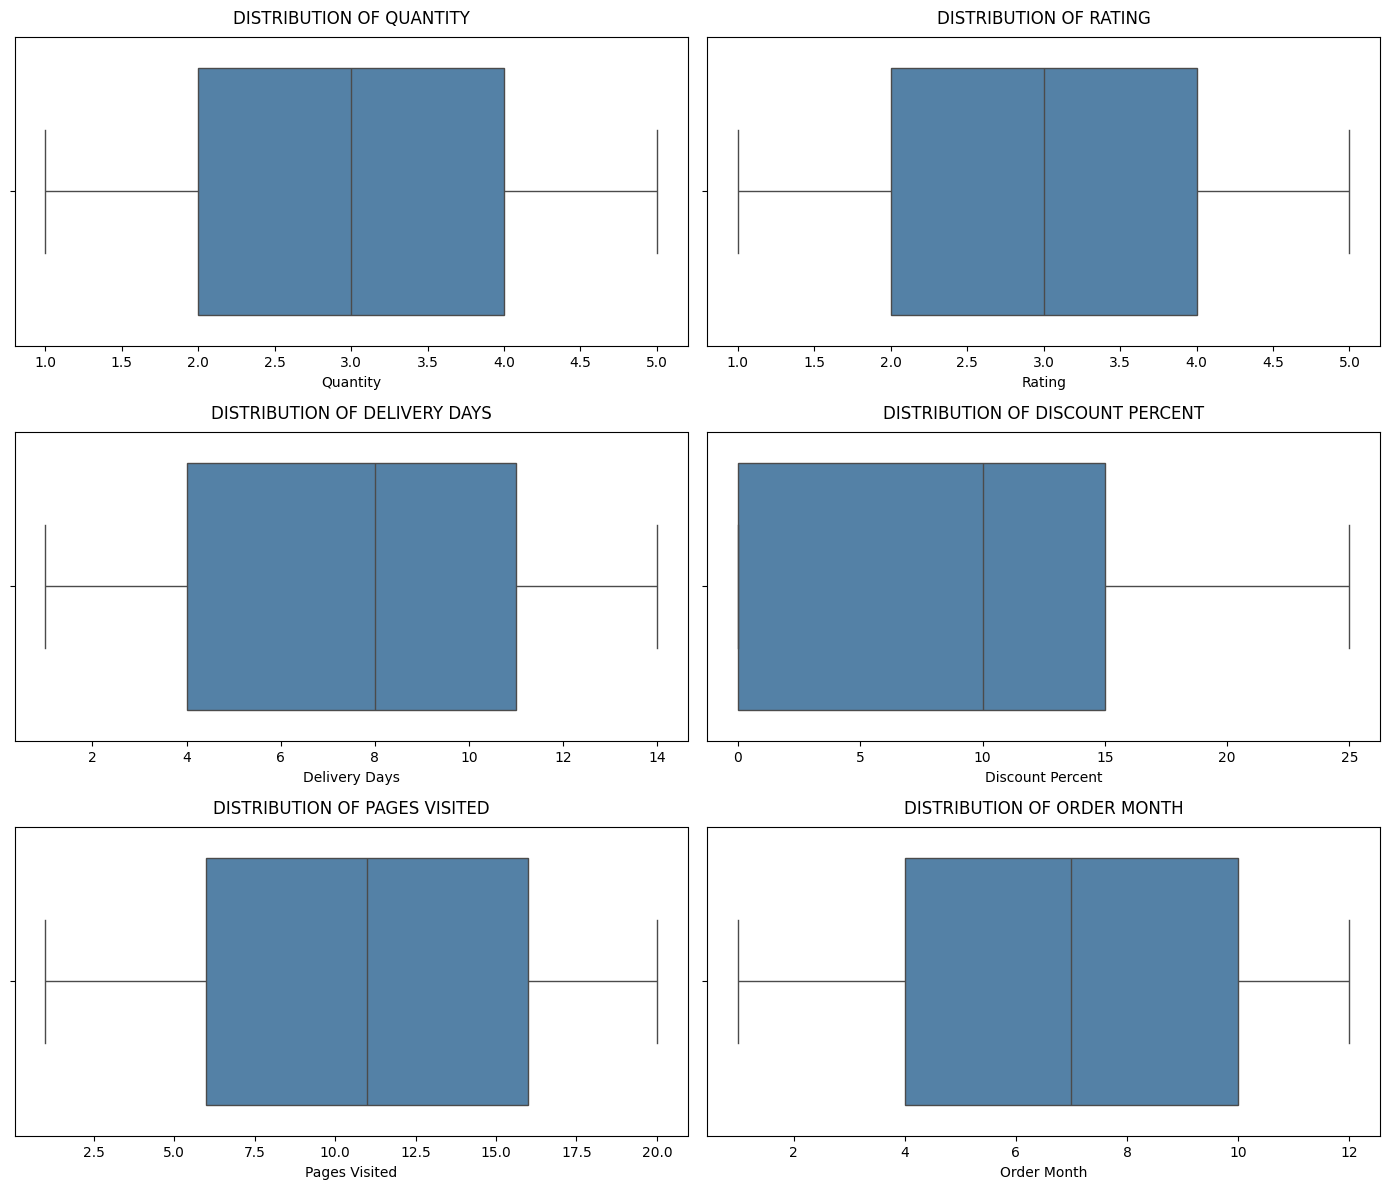

In [12]:
# Boxplot Distribution of Discrete Variables
n_cols = 2
n_rows = math.ceil(len(discrete_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()  
for i, cons in enumerate(discrete_cols):
    ax = axes[i]
    
    sns.boxplot(
        data=eda_df,
        x=cons,
        ax=ax,
        color='steelblue'
    )
    
    # Title & labels
    title = f'Distribution of {cons.replace("_", " ")}'.upper()
    xlabel = cons.replace('_', ' ').title().replace('Usd', 'USD')
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)

# Hide empty subplots if not exact multiple of 2
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Bar Graph for Discrete and Categorical

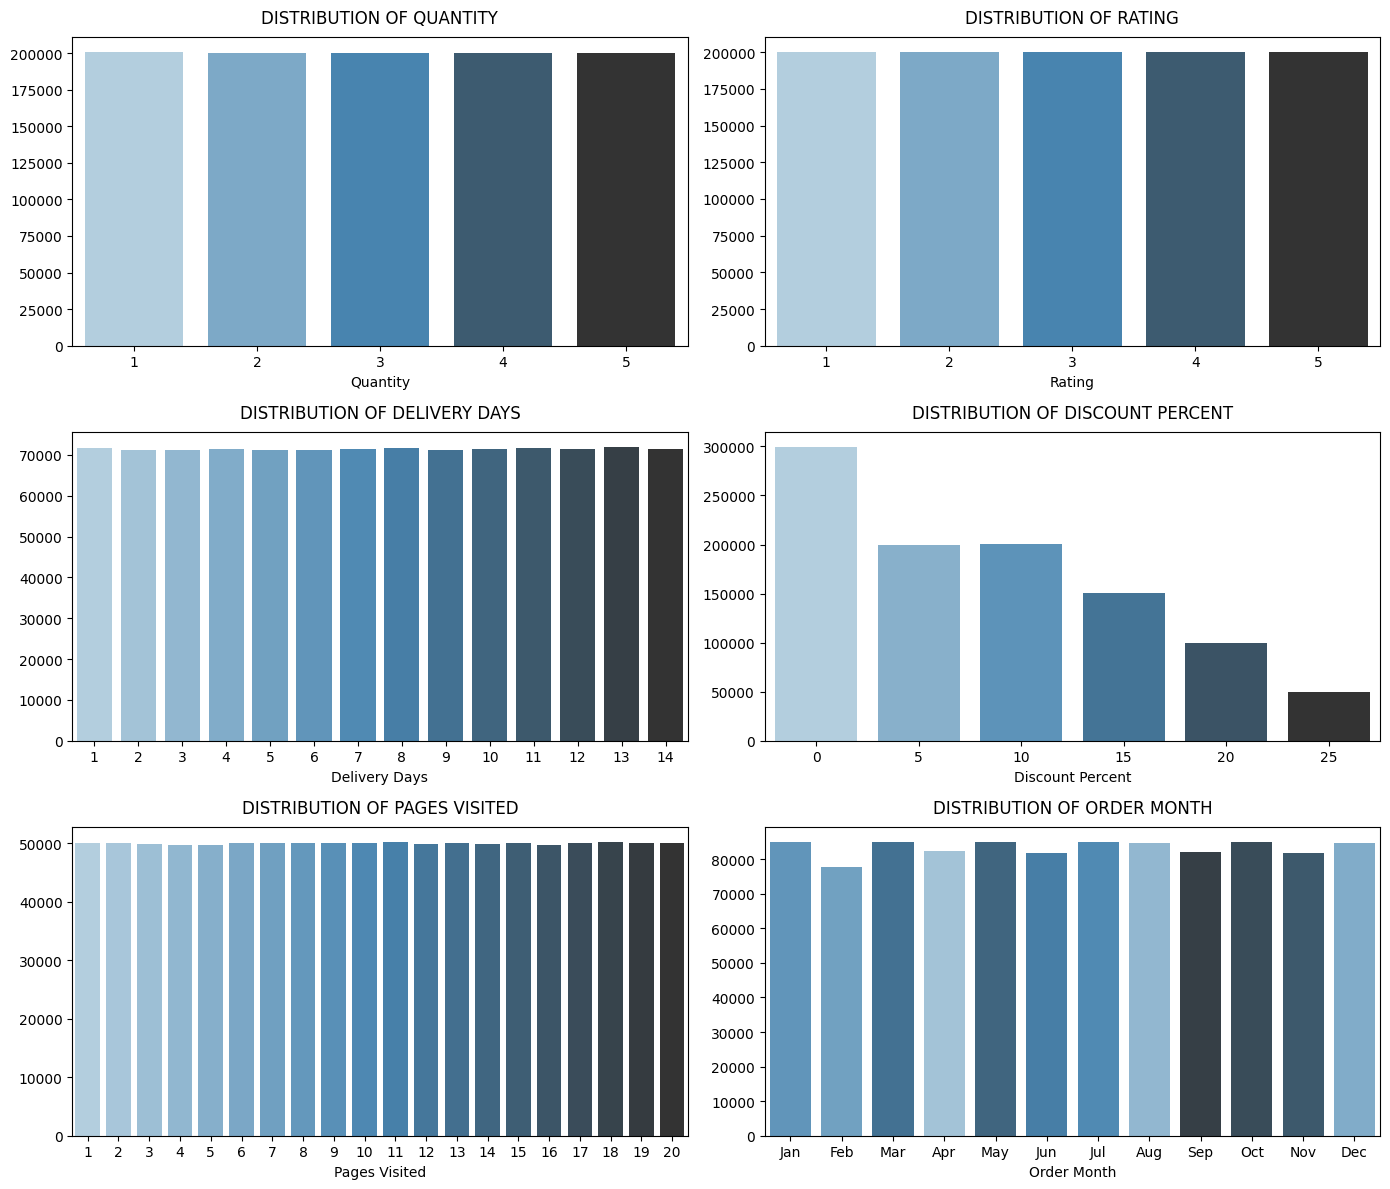

In [13]:
# Bar Graph of Discrete Variables
n_cols = 2
n_rows = math.ceil(len(discrete_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()  

# Custom order for column that has natural sequence
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

eda_df['order_month'] = eda_df['order_month'].map(month_map)

# Then use this custom_order
custom_order = {
    'order_month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
}

for i, cons in enumerate(discrete_cols):
    ax = axes[i]
    count_plot = eda_df[cons].value_counts().sort_index()
    
    order = custom_order.get(cons, count_plot.index)
    
    sns.barplot(
        x=count_plot.index,
        y=count_plot.values,
        ax=ax,
        color='steelblue',
        palette='Blues_d',
        legend=False,
        hue=count_plot.index,
        order=order
    )
    
    # Title & labels
    title = f'Distribution of {cons.replace("_", " ")}'.upper()
    xlabel = cons.replace('_', ' ').title().replace('Usd', 'USD')
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)

# Hide empty subplots if not exact multiple of 2
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

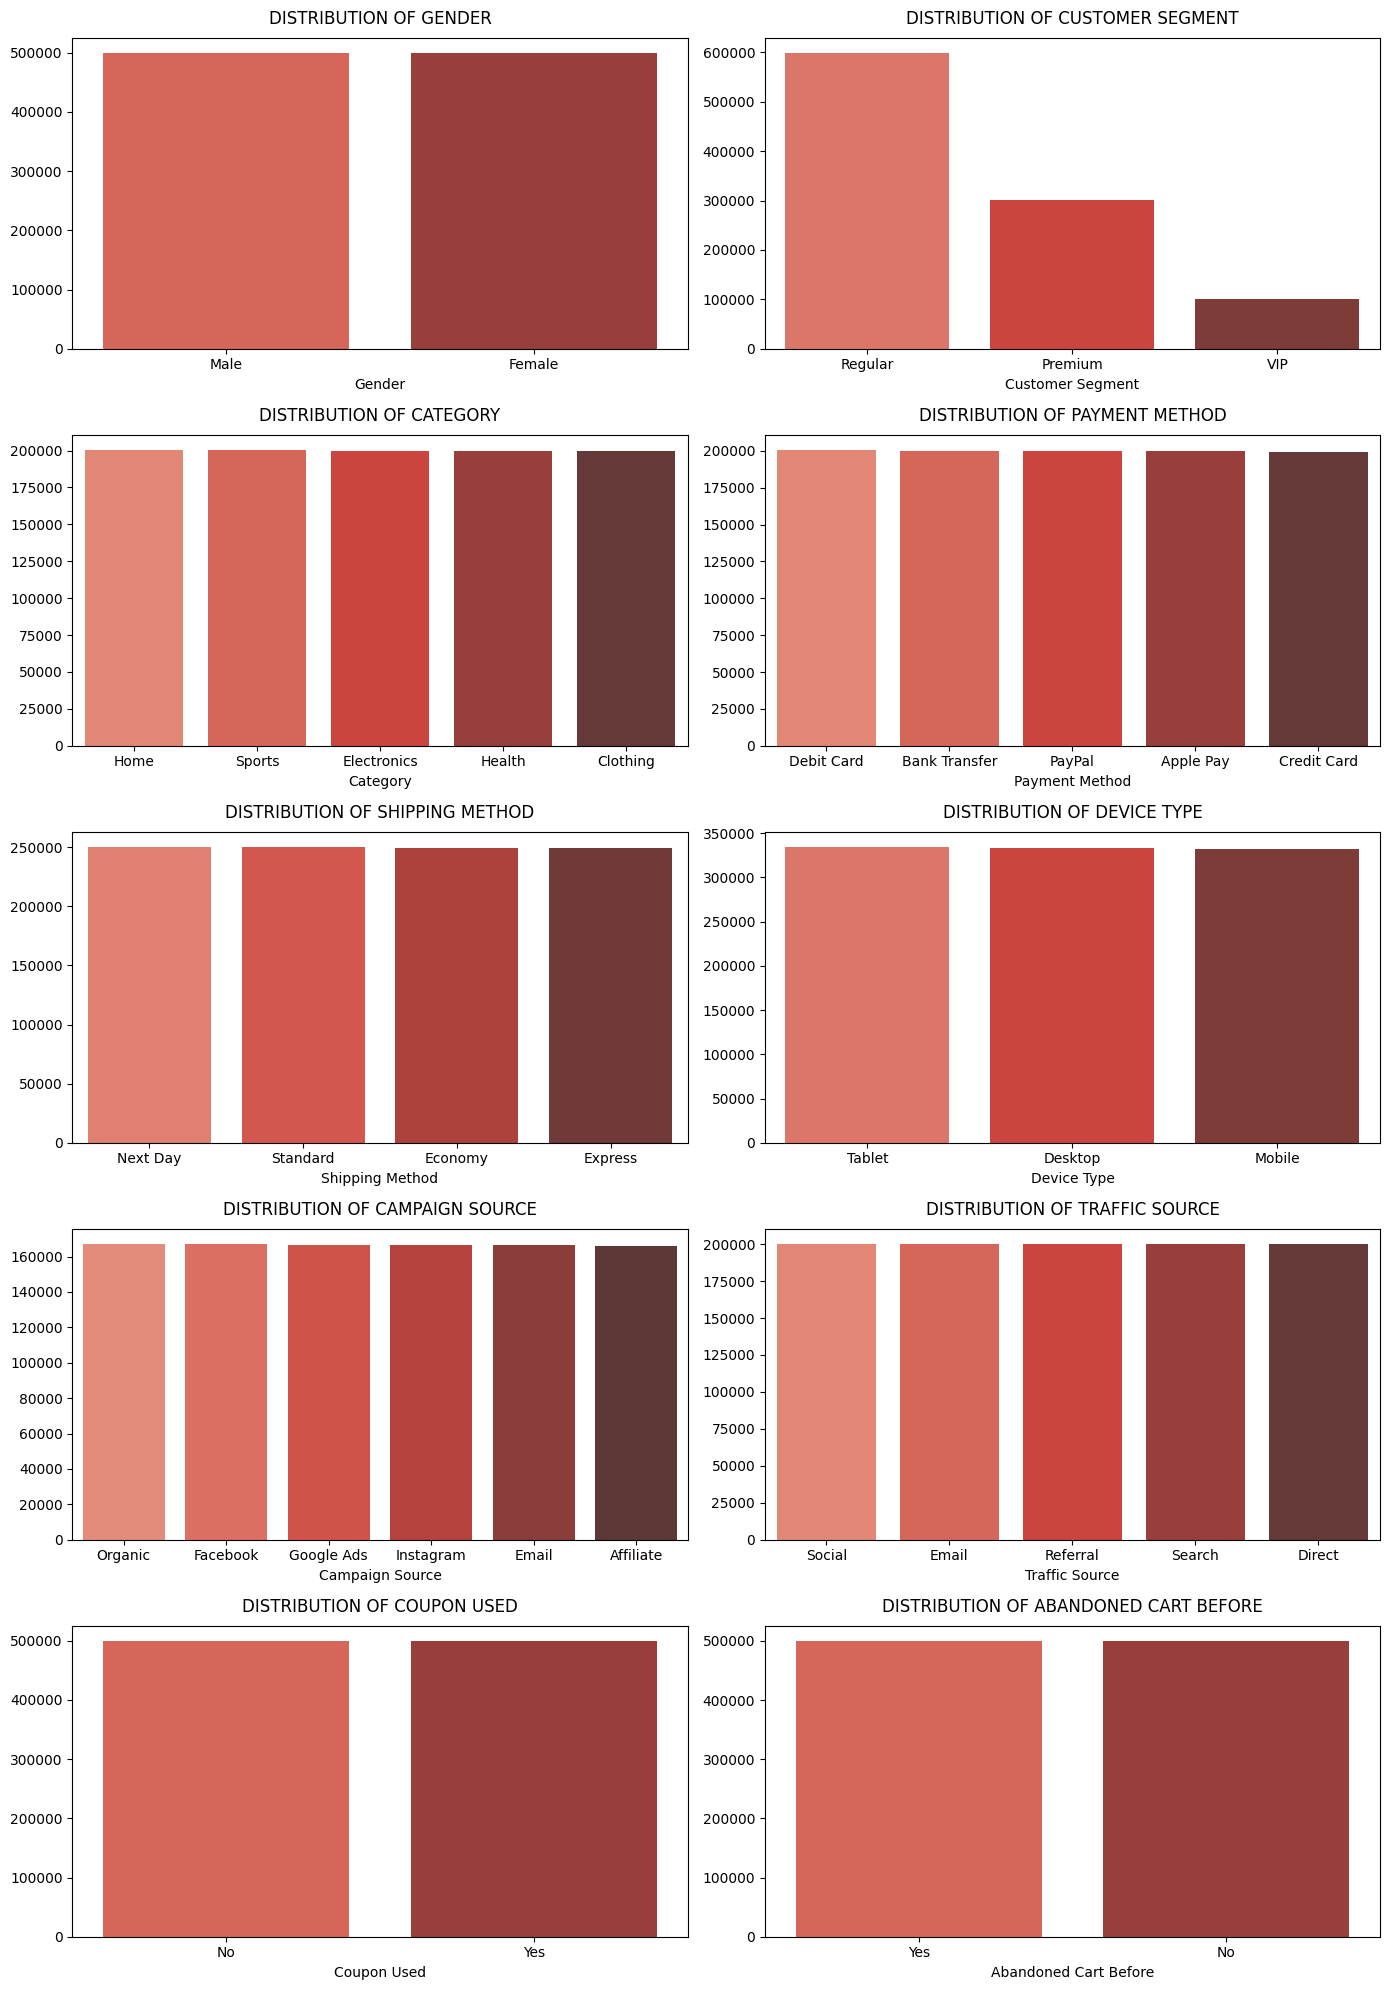

In [14]:
# Bar Graph of Categorical Variables
n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()  


for i, cons in enumerate(categorical_cols):
    ax = axes[i]
    count_plot = eda_df[cons].value_counts().sort_values(ascending=False)
    
    sns.barplot(
        x=count_plot.index,
        y=count_plot.values,
        ax=ax,
        color='steelblue',
        palette='Reds_d',
        legend=False,
        hue=count_plot.index,
    )
    
    # Title & labels
    title = f'Distribution of {cons.replace("_", " ")}'.upper()
    xlabel = cons.replace('_', ' ').title().replace('Usd', 'USD')
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)

# Hide empty subplots if not exact multiple of 2
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

The visualizations of histogram, boxplot, and bar graph provided a comprehensive understanding of the distributions of the continuous, discrete, and categorical variables. While the IQR method identified potential outliers in several numerical features, the histograms and box plots indicate that these observations are consistent with the underlying data distribution rather than being apparent anomalies. Since the identified values likely represent legitimate business transactions and natural variability within the dataset, no outlier treatment was applied. Retaining these observations helps preserve the integrity of the data and ensures that the analysis reflects realistic business behavior.

### Heatmap, Correlation, and Pairplot

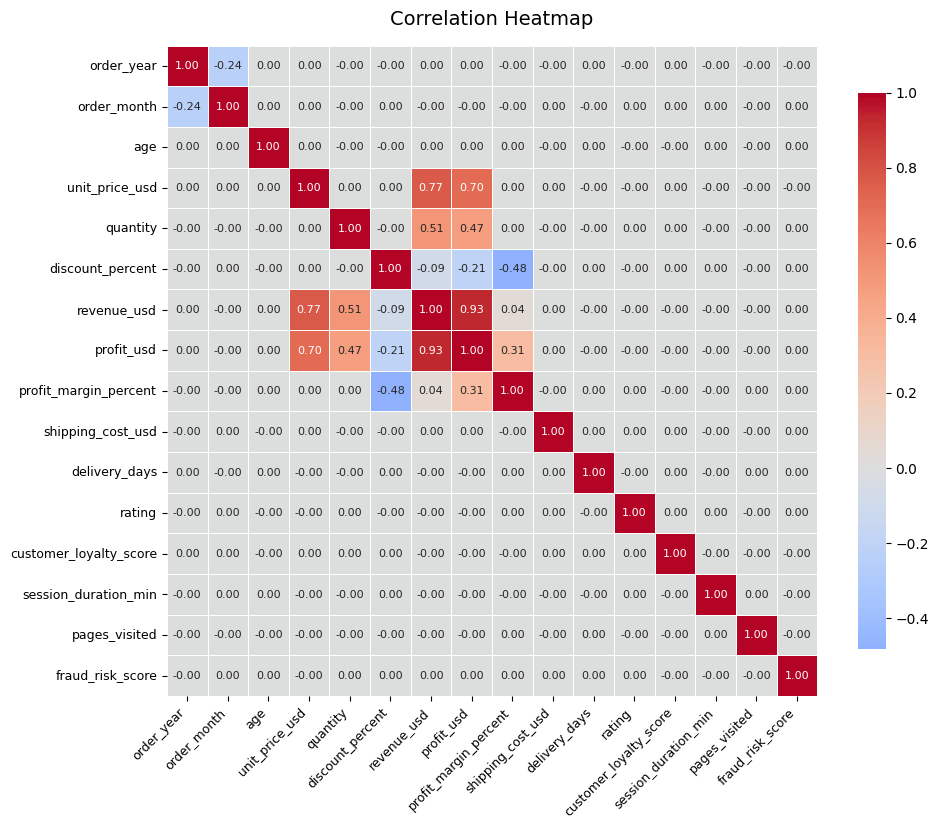

In [ ]:
# Heatmap of Correlation Matrix

n = len(numeric_cols.columns)
fig_size = max(10, n * 0.6)         

plt.figure(figsize=(fig_size, fig_size * 0.85))

corr = numeric_cols.corr()

sns.heatmap(
    data=corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}
)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.title('Correlation Heatmap', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

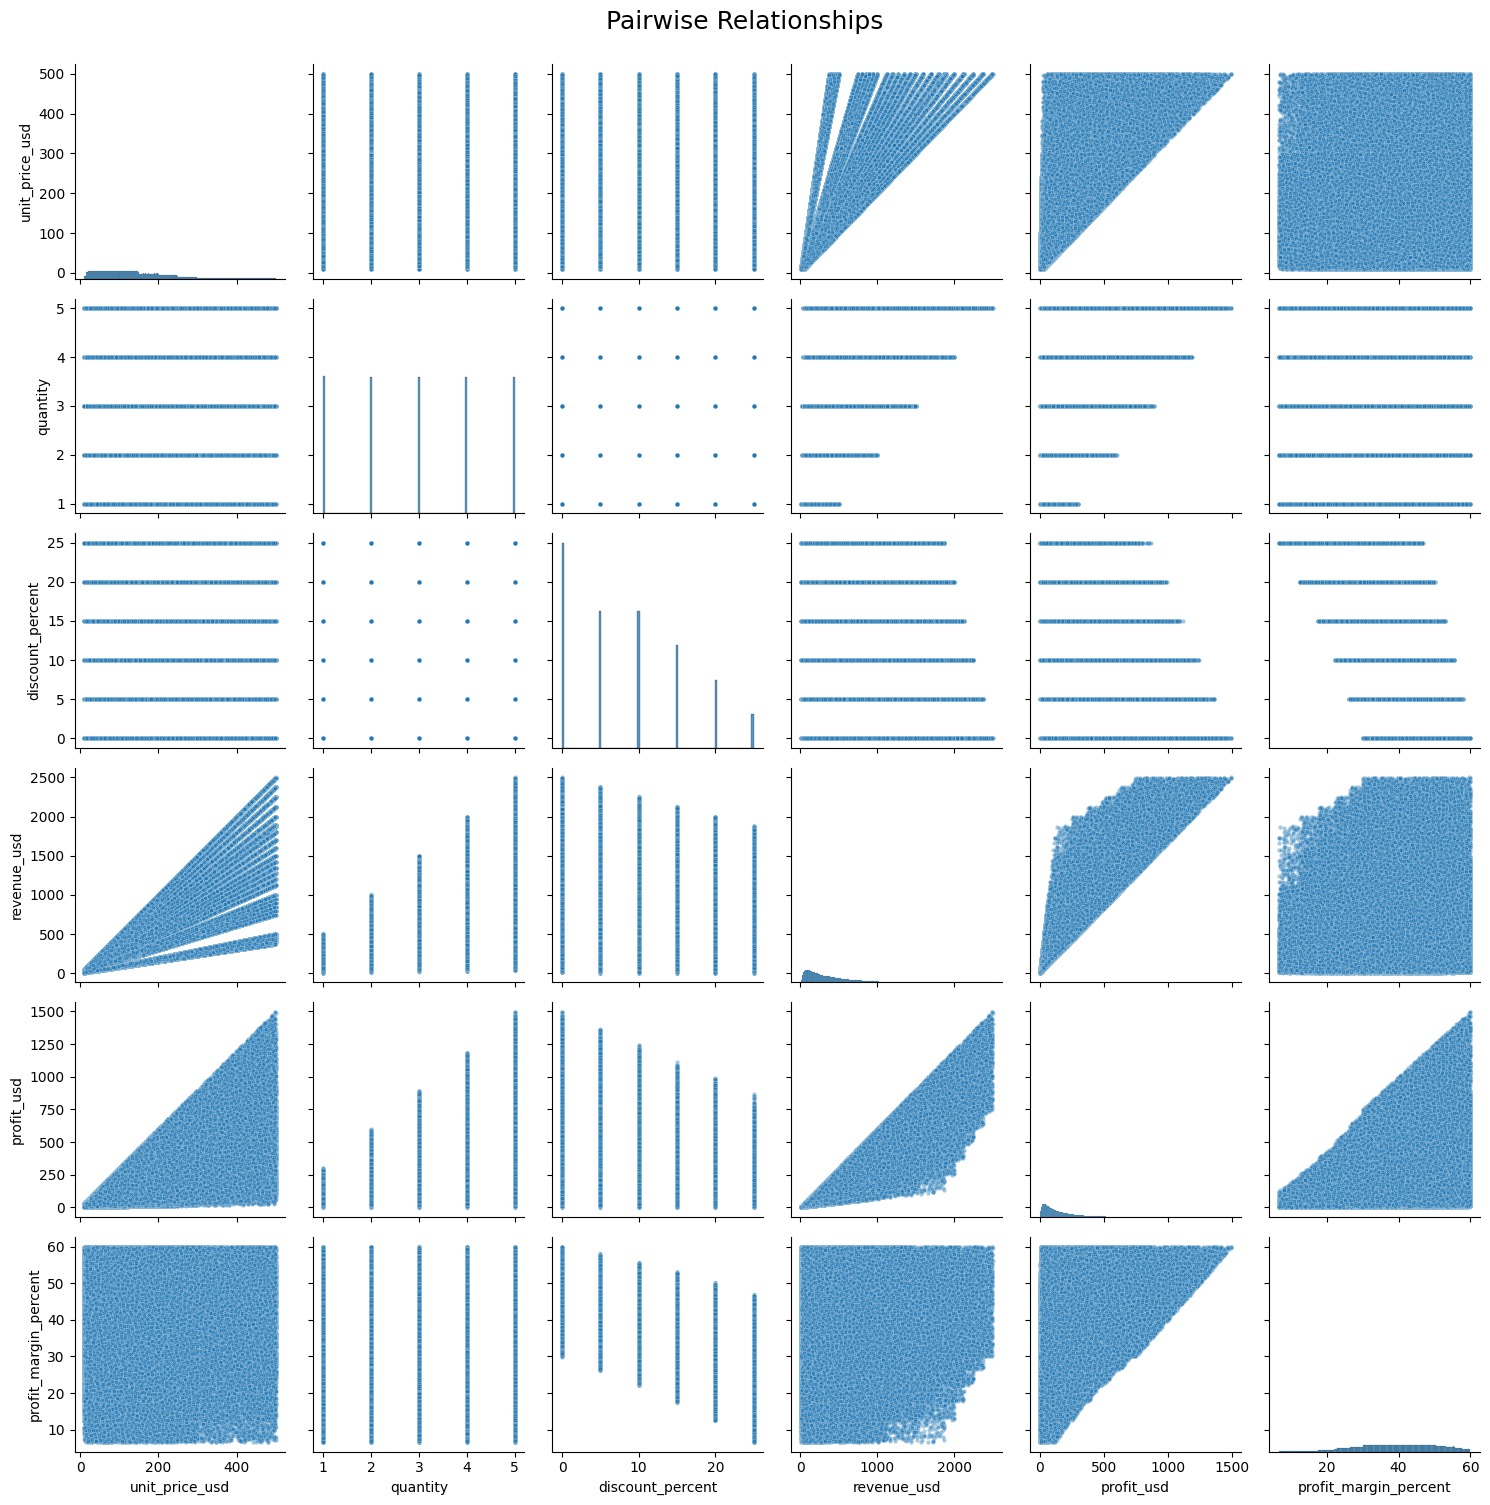

In [ ]:
# Pairwise Relationships

selected_cols = [
    'unit_price_usd',
    'quantity',
    'discount_percent',
    'revenue_usd',
    'profit_usd',
    'profit_margin_percent'
]

g = sns.pairplot(
    eda_df[selected_cols],
    diag_kind='hist',
    plot_kws={'alpha': 0.4, 's': 10},
)

g.fig.suptitle('Pairwise Relationships', fontsize=18, y=1)

plt.tight_layout()
plt.show()

``Revenue`` exhibits a **strong positive relationship** with ``unit price`` **(r = 0.77)** and a **moderate positive relationship** with purchase quantity **(r = 0.51)**, indicating that both pricing and purchase volume contribute to higher transaction values. ``Unit price`` and purchase ``quantity``, however, show little to **no linear relationship**, suggesting that customers purchasing higher-priced products are not necessarily buying larger quantities. Additionally, ``discount percentage`` has a **moderate negative relationship** with ``profit margin`` **(r = -0.48)** while showing minimal association with purchase quantity, indicating that larger discounts reduce profitability without a meaningful increase in sales volume. These findings provide an initial understanding of the dataset's relationships and patterns, serving as a foundation for the subsequent feature engineering and domain-specific analyses of sales, customers, marketing, and logistics.